In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"
TRAIN_IMAGES = DATA_DIR / "images" / "train"

print("Dataset:", DATA_DIR)
print("Training images:", TRAIN_IMAGES)

Dataset: /Users/priyansh/Downloads/airport-baggage-screening/data
Training images: /Users/priyansh/Downloads/airport-baggage-screening/data/images/train


In [10]:
image_paths = sorted(TRAIN_IMAGES.glob("*.jpg"))

sample_path = image_paths[0]

image = cv2.imread(str(sample_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image:", sample_path.name)
print("Shape:", image_rgb.shape)

Image: PID_xray_00000.jpg
Shape: (448, 620, 3)


In [11]:
def apply_clahe(image):
    """
    Apply CLAHE contrast enhancement to an X-ray image.
    """

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced_l = clahe.apply(l_channel)

    enhanced_lab = cv2.merge(
        [enhanced_l, a_channel, b_channel]
    )

    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced

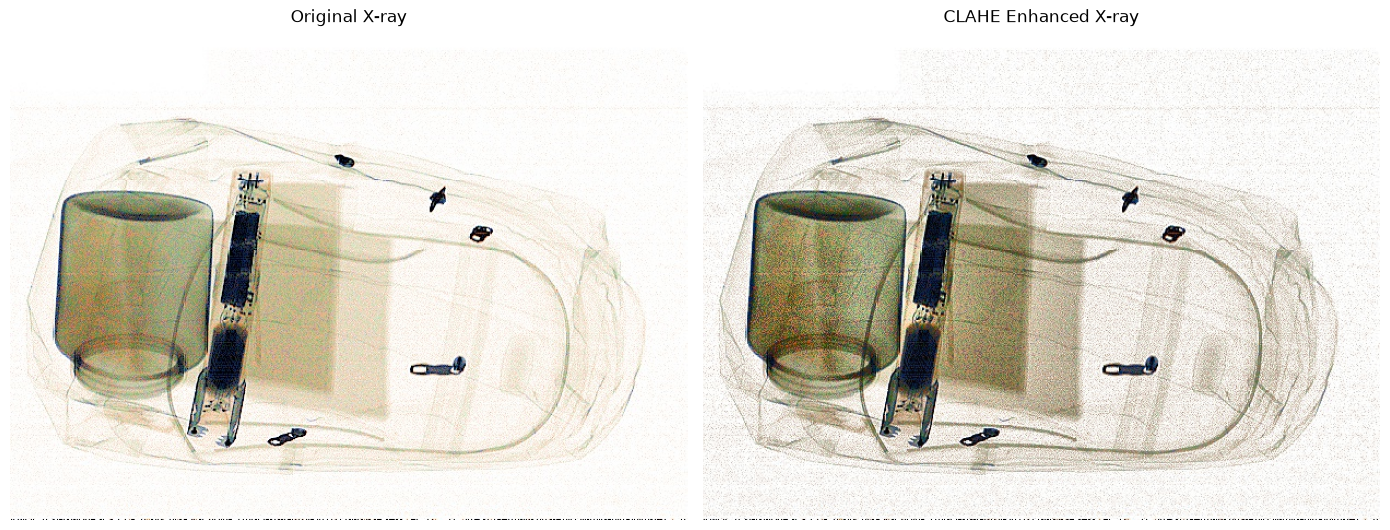

In [12]:
enhanced_image = apply_clahe(image_rgb)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_image)
plt.title("CLAHE Enhanced X-ray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
def apply_denoising(image):
    """
    Apply mild Gaussian denoising.
    """

    return cv2.GaussianBlur(
        image,
        (3, 3),
        0
    )

In [14]:
def preprocess_xray(image):
    """
    Denoising + CLAHE preprocessing pipeline.
    """

    denoised = apply_denoising(image)

    enhanced = apply_clahe(denoised)

    return enhanced

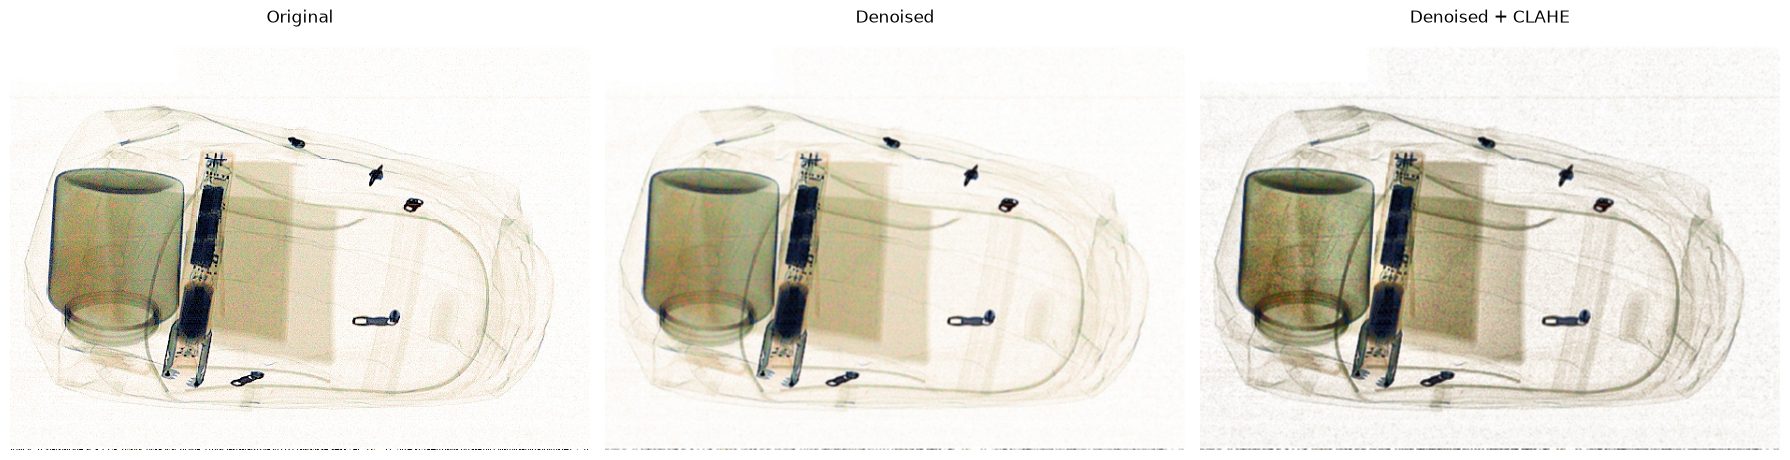

In [15]:
denoised = apply_denoising(image_rgb)
processed = preprocess_xray(image_rgb)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(denoised)
plt.title("Denoised")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(processed)
plt.title("Denoised + CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

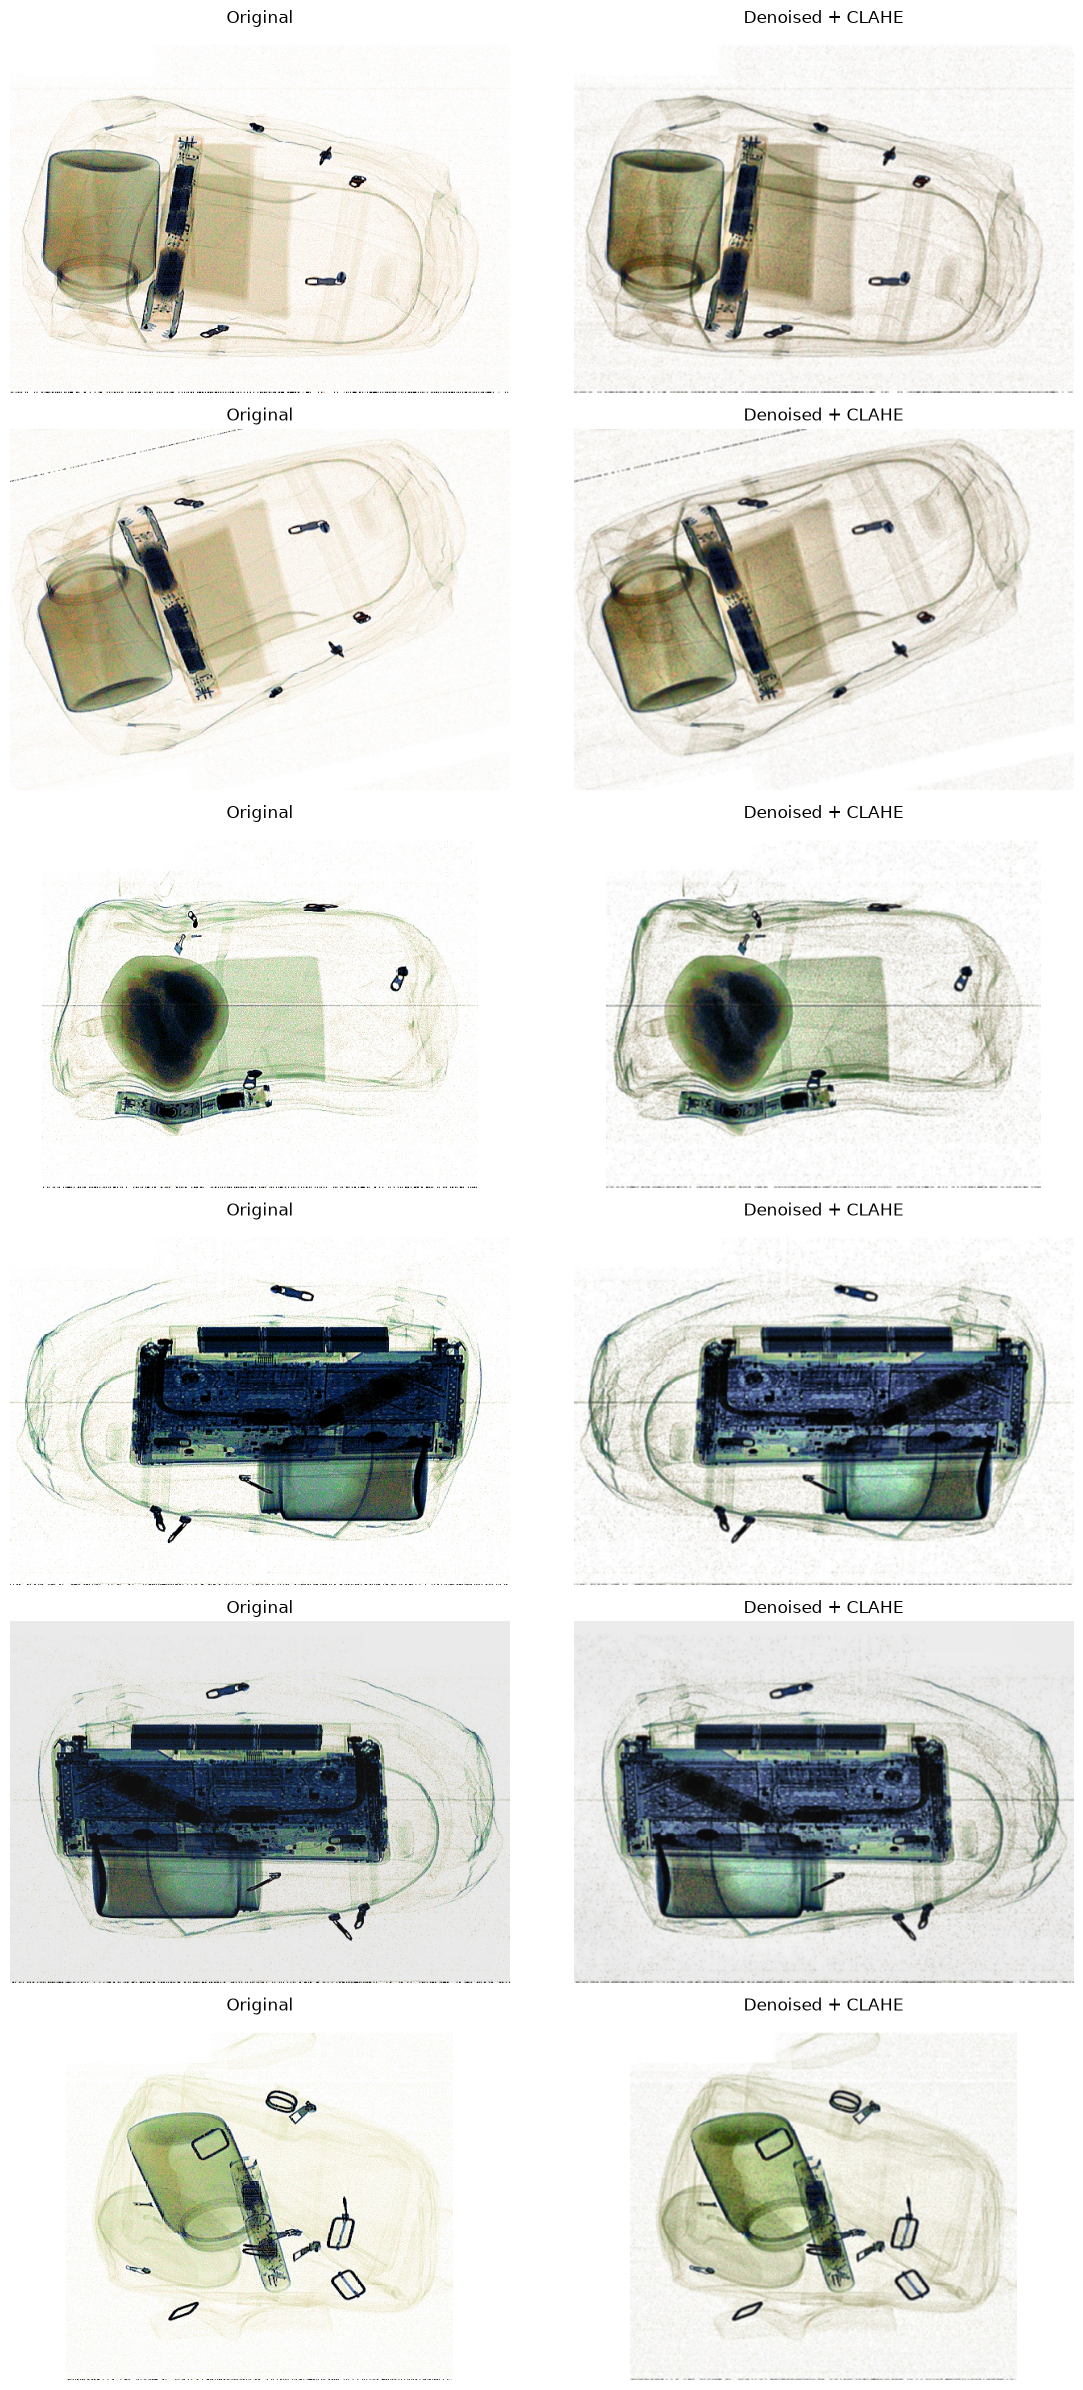

In [16]:
sample_paths = image_paths[:6]

fig, axes = plt.subplots(
    len(sample_paths),
    2,
    figsize=(12, 4 * len(sample_paths))
)

for row, path in enumerate(sample_paths):

    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    processed = preprocess_xray(img)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(processed)
    axes[row, 1].set_title("Denoised + CLAHE")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()